# EDA — `hey_clientes.csv`

**Autor:** Diego Quiros | DS Lead — datamoles  
**Proyecto:** Havi — Copiloto financiero proactivo · DSC x Hey 2026  
**Fecha:** Abril 2026

---

Este notebook es el análisis exploratorio de la tabla de clientes de Hey Banco.  
Es el **punto de partida** para todos los use cases — casi todo join en el proyecto pasa por `user_id` de este dataset.

**Objetivo:** entender la estructura demográfica y de segmentación de la base de clientes, detectar problemas de calidad de datos, e identificar features candidatas para UC2 (Gemelo Digital) y UC3 (Upselling).

---
## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display options — ver todas las columnas y floats limpios
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 100)

# Tema global de seaborn
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# ── Constantes ──────────────────────────────────────────────────────────────
from pathlib import Path
DATA_PATH = Path(r'/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones/hey_clientes.csv')

print('✓ Setup completo')

✓ Setup completo


---
## 1. Carga del Dataset

`hey_clientes.csv` es la **tabla de dimensión central** del proyecto.  
Contiene datos demográficos y señales de comportamiento de los usuarios de Hey Banco.  
Toda consulta cross-dataset usa `user_id` como join key hacia esta tabla.

In [2]:
%%time
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Shape: 15,025 filas × 22 columnas
CPU times: user 19.1 ms, sys: 5.16 ms, total: 24.2 ms
Wall time: 26 ms


---
## 2. Inspección General

In [3]:
# Primeras 10 filas — primer vistazo a los datos reales
df.head(10)

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,canal_apertura,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,False,App,527,1,app_android,10.00,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,False,App,714,3,app_android,8.00,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,False,App,454,3,app_ios,8.00,False,True,es_MX,False,2,False
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,False,Fan Shop,837,16,app_ios,10.00,True,False,es_MX,True,3,False
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,False,Fan Shop,533,1,app_ios,7.00,False,True,es_MX,True,2,False
5,USR-00006,27,H,Otros,Zacatecas,Licenciatura,Empleado,28000,1215,True,False,App,502,1,app_android,9.00,False,False,es_MX,True,2,False
6,USR-00007,41,SE,Baja California,Mexicali,Secundaria,Empleado,32000,1345,True,True,App,615,8,app_android,9.00,False,True,es_MX,True,4,False
7,USR-00008,31,H,NaN,NaN,Licenciatura,Empleado,11500,1117,True,False,App,601,0,app_android,10.00,False,True,es_MX,True,2,False
8,USR-00009,54,H,Nuevo León,San Nicolás de los Garza,Preparatoria,Empleado,19500,185,False,True,App,665,7,app_android,9.00,False,True,es_MX,False,2,False
9,USR-00010,26,H,Coahuila,Monclova,Preparatoria,Independiente,23500,357,False,False,Fan Shop,609,2,app_ios,7.00,False,False,es_MX,False,1,False


In [4]:
# Tipos de datos y memoria — detectar columnas con tipo incorrecto temprano
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15025 entries, 0 to 15024
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  15025 non-null  str    
 1   edad                     15025 non-null  int64  
 2   sexo                     15025 non-null  str    
 3   estado                   14593 non-null  str    
 4   ciudad                   14593 non-null  str    
 5   nivel_educativo          15025 non-null  str    
 6   ocupacion                15025 non-null  str    
 7   ingreso_mensual_mxn      15025 non-null  int64  
 8   antiguedad_dias          15025 non-null  int64  
 9   es_hey_pro               15025 non-null  bool   
 10  nomina_domiciliada       15025 non-null  bool   
 11  canal_apertura           15025 non-null  str    
 12  score_buro               15025 non-null  int64  
 13  dias_desde_ultimo_login  15025 non-null  int64  
 14  preferencia_canal        15025 no

In [5]:
# Estadísticas descriptivas completas — incluye categóricas con include='all'
df.describe(include='all')

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,canal_apertura,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
count,15025,15025.00,15025,14593,14593,15025,15025,15025.00,15025.00,15025,15025,15025,15025.00,15025.00,15025,14274.00,15025,15025,15025,15025,15025.00,15025
unique,15025,NaN,3,17,83,4,6,NaN,NaN,2,2,2,NaN,NaN,3,NaN,2,2,2,2,NaN,2
top,USR-00001,NaN,M,Ciudad de México,CDMX - Tlalpan,Licenciatura,Empleado,NaN,NaN,False,False,App,NaN,NaN,app_ios,NaN,False,False,es_MX,False,NaN,False
freq,1,NaN,7281,2627,538,6616,8550,NaN,NaN,7680,9897,12189,NaN,NaN,6641,NaN,13774,10768,14544,10883,NaN,14262
mean,NaN,37.19,NaN,NaN,NaN,NaN,NaN,29793.68,935.11,NaN,NaN,NaN,618.45,18.77,NaN,7.48,NaN,NaN,NaN,NaN,2.23,NaN
std,NaN,10.19,NaN,NaN,NaN,NaN,NaN,19171.16,512.96,NaN,NaN,NaN,127.16,35.31,NaN,1.88,NaN,NaN,NaN,NaN,1.14,NaN
min,NaN,18.00,NaN,NaN,NaN,NaN,NaN,4500.00,7.00,NaN,NaN,NaN,295.00,0.00,NaN,3.00,NaN,NaN,NaN,NaN,0.00,NaN
25%,NaN,29.00,NaN,NaN,NaN,NaN,NaN,16000.00,490.00,NaN,NaN,NaN,529.00,2.00,NaN,6.00,NaN,NaN,NaN,NaN,1.00,NaN
50%,NaN,36.00,NaN,NaN,NaN,NaN,NaN,24000.00,942.00,NaN,NaN,NaN,631.00,7.00,NaN,8.00,NaN,NaN,NaN,NaN,2.00,NaN
75%,NaN,45.00,NaN,NaN,NaN,NaN,NaN,37000.00,1375.00,NaN,NaN,NaN,719.00,15.00,NaN,9.00,NaN,NaN,NaN,NaN,3.00,NaN


In [6]:
# Lista de columnas con sus dtypes — útil para referencia rápida durante el notebook
col_info = pd.DataFrame({
    'columna': df.columns,
    'dtype': df.dtypes.values,
    'nunique': df.nunique().values,
    'ejemplo': [df[c].dropna().iloc[0] if df[c].notna().any() else 'N/A' for c in df.columns]
})
col_info

,columna,dtype,nunique,ejemplo
0,user_id,str,15025,USR-00001
1,edad,int64,43,21
2,sexo,str,3,M
3,estado,str,17,Ciudad de México
4,ciudad,str,83,CDMX - Benito Juárez
5,nivel_educativo,str,4,Preparatoria
6,ocupacion,str,6,Empleado
7,ingreso_mensual_mxn,int64,151,24500
8,antiguedad_dias,int64,1816,1554
9,es_hey_pro,bool,2,True


---
## 3. Calidad de Datos

In [7]:
# ── Nulos por columna ────────────────────────────────────────────────────────
# Ordenar descendente para ver los peores problemas primero
null_df = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('pct_nulos', ascending=False)

null_df[null_df['nulos'] > 0].style.background_gradient(subset=['pct_nulos'], cmap='Reds')

,nulos,pct_nulos
satisfaccion_1_10,751,5.000000
estado,432,2.880000
ciudad,432,2.880000


In [8]:
# ── Columnas con >50% nulos — candidatas a drop ──────────────────────────────
cols_high_null = null_df[null_df['pct_nulos'] > 50].index.tolist()
if cols_high_null:
    print(f'⚠️  Columnas con >50% nulos ({len(cols_high_null)}): {cols_high_null}')
else:
    print('✓ Ninguna columna supera el 50% de nulos')

✓ Ninguna columna supera el 50% de nulos


In [9]:
# ── Duplicados por user_id ───────────────────────────────────────────────────
# user_id DEBE ser único — es la PK de esta tabla
uid_col = next((c for c in df.columns if 'user_id' in c.lower() or c.lower() == 'id'), None)

if uid_col:
    n_total = len(df)
    n_unique = df[uid_col].nunique()
    n_dupes = df.duplicated(subset=[uid_col]).sum()
    print(f'Columna ID detectada: "{uid_col}"')
    print(f'Total filas:     {n_total:,}')
    print(f'user_id únicos:  {n_unique:,}')
    if n_dupes > 0:
        print(f'⚠️  DUPLICADOS: {n_dupes:,} filas tienen user_id repetido — revisar antes de hacer joins')
    else:
        print('✓ user_id es único — tabla de dimensión válida')
else:
    print('⚠️  No se encontró columna user_id — revisar nombres de columnas')

Columna ID detectada: "user_id"
Total filas:     15,025
user_id únicos:  15,025
✓ user_id es único — tabla de dimensión válida


In [10]:
# ── Filas completamente duplicadas ───────────────────────────────────────────
n_full_dupes = df.duplicated().sum()
print(f'Filas completamente duplicadas: {n_full_dupes:,}')

Filas completamente duplicadas: 0


In [11]:
# ── Columnas constantes (un solo valor único) — inútiles para modelado ───────
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
if constant_cols:
    print(f'⚠️  Columnas constantes ({len(constant_cols)}): {constant_cols}')
else:
    print('✓ No hay columnas constantes')

✓ No hay columnas constantes


---
## 4. Análisis Demográfico

La demografía es la base del **UC2 (Gemelo Digital)**: necesitamos entender qué tipos de usuarios existen para construir personas financieras coherentes.

In [12]:
# ── Detección dinámica de columna de edad ────────────────────────────────────
age_col = next((c for c in df.columns if 'edad' in c.lower() or 'age' in c.lower()), None)
print(f'Columna de edad detectada: {age_col}')

Columna de edad detectada: edad


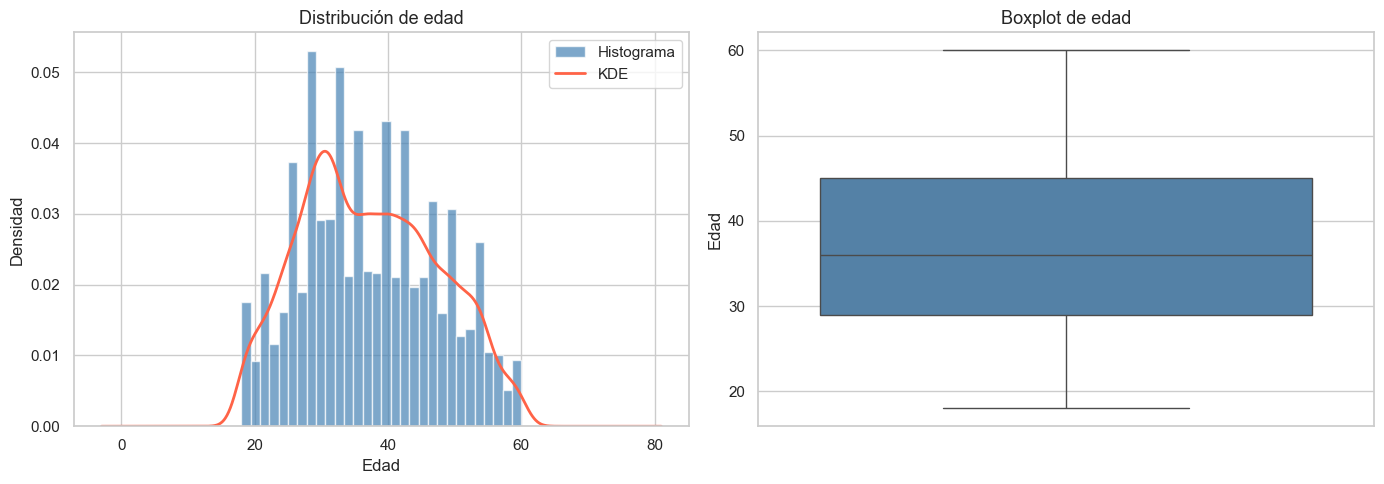


Estadísticas de edad:
count   15025.00
mean       37.19
std        10.19
min        18.00
25%        29.00
50%        36.00
75%        45.00
max        60.00
Name: edad, dtype: float64


In [13]:
if age_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma + KDE: distribución real de edades
    age_data = df[age_col].dropna()
    axes[0].hist(age_data, bins=30, color='steelblue', alpha=0.7, density=True, label='Histograma')
    age_data.plot(kind='kde', ax=axes[0], color='tomato', linewidth=2, label='KDE')
    axes[0].set_title(f'Distribución de {age_col}', fontsize=13)
    axes[0].set_xlabel('Edad')
    axes[0].set_ylabel('Densidad')
    axes[0].legend()

    # Boxplot: ver rangos y outliers rápido
    sns.boxplot(y=age_data, ax=axes[1], color='steelblue')
    axes[1].set_title(f'Boxplot de {age_col}', fontsize=13)
    axes[1].set_ylabel('Edad')

    plt.tight_layout()
    plt.show()

    print(f'\nEstadísticas de {age_col}:')
    print(age_data.describe())
else:
    print('⚠️  No se encontró columna de edad')

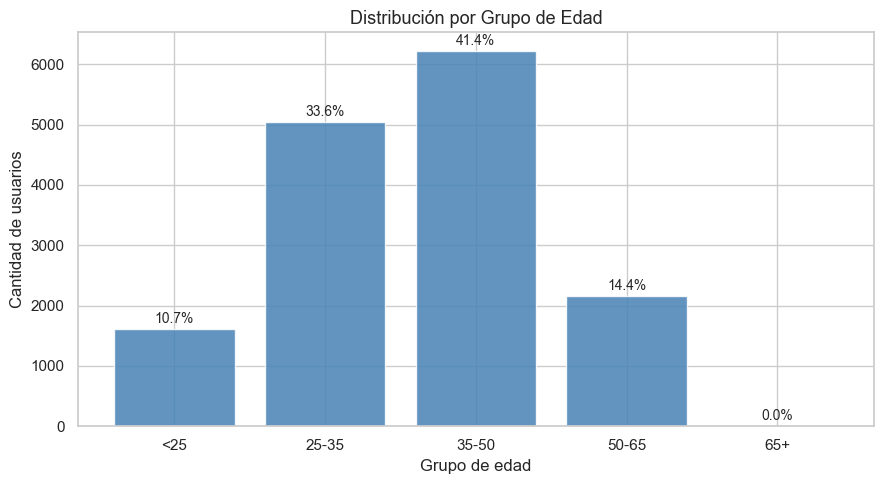

              count   pct
feat_age_bin             
<25            1604 10.70
25-35          5043 33.60
35-50          6217 41.40
50-65          2161 14.40
65+               0  0.00


In [14]:
if age_col:
    # Bins estándar para personas financieras — alineados con frameworks de segmentación
    bins = [0, 25, 35, 50, 65, 200]
    labels = ['<25', '25-35', '35-50', '50-65', '65+']
    df['feat_age_bin'] = pd.cut(df[age_col], bins=bins, labels=labels, right=False)

    age_bin_counts = df['feat_age_bin'].value_counts().sort_index()
    age_bin_pct = (age_bin_counts / age_bin_counts.sum() * 100).round(1)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(age_bin_counts.index.astype(str), age_bin_counts.values, color='steelblue', alpha=0.85)

    for bar, pct in zip(bars, age_bin_pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f'{pct}%', ha='center', va='bottom', fontsize=10)

    ax.set_title('Distribución por Grupo de Edad', fontsize=13)
    ax.set_xlabel('Grupo de edad')
    ax.set_ylabel('Cantidad de usuarios')
    plt.tight_layout()
    plt.show()

    print(age_bin_counts.to_frame('count').assign(pct=age_bin_pct))

Columna de género detectada: sexo


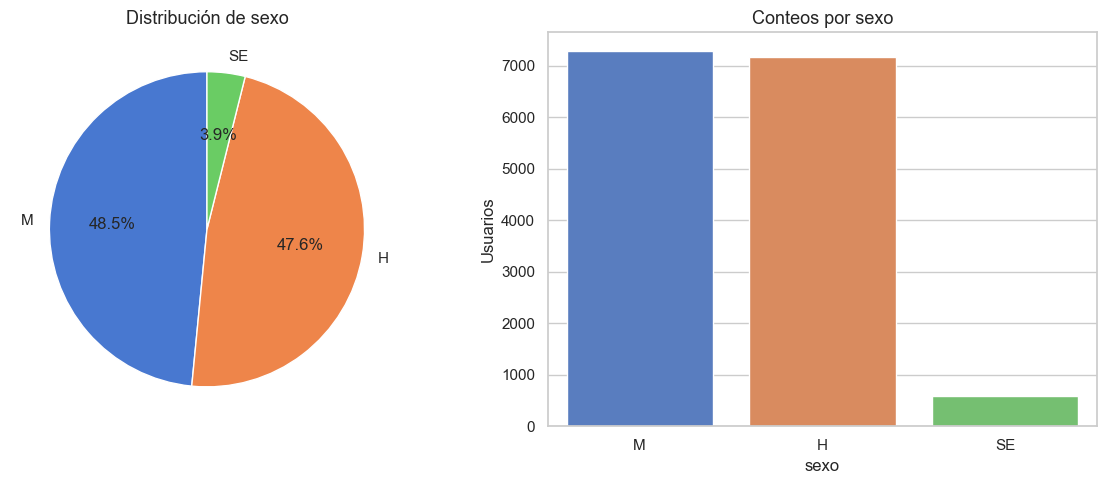

sexo
M     7281
H     7157
SE     587
Name: count, dtype: int64


In [15]:
# ── Género ────────────────────────────────────────────────────────────────────
gender_col = next((c for c in df.columns if any(k in c.lower() for k in ['genero', 'gender', 'sexo', 'sex'])), None)
print(f'Columna de género detectada: {gender_col}')

if gender_col:
    gender_counts = df[gender_col].value_counts(dropna=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Pie chart
    axes[0].pie(gender_counts.values, labels=gender_counts.index.astype(str),
                autopct='%1.1f%%', startangle=90,
                colors=sns.color_palette('muted', len(gender_counts)))
    axes[0].set_title(f'Distribución de {gender_col}', fontsize=13)

    # Bar chart con conteos exactos
    sns.barplot(x=gender_counts.index.astype(str), y=gender_counts.values,
                palette='muted', ax=axes[1])
    axes[1].set_title(f'Conteos por {gender_col}', fontsize=13)
    axes[1].set_xlabel(gender_col)
    axes[1].set_ylabel('Usuarios')

    plt.tight_layout()
    plt.show()
    print(gender_counts)

Columna de estado/región detectada: estado


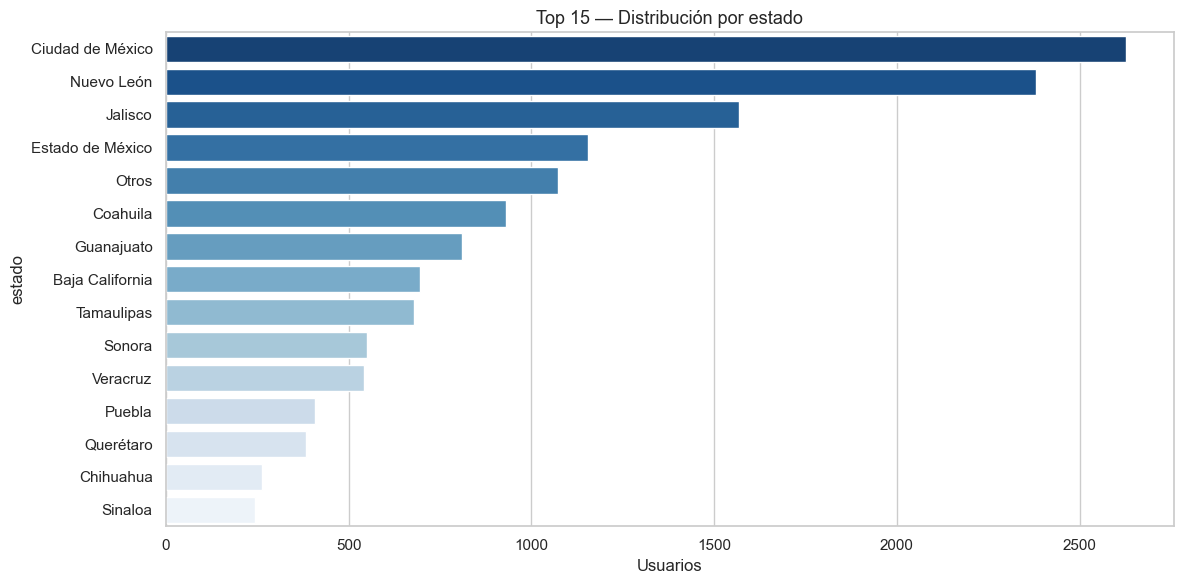

In [16]:
# ── Estado / Región ───────────────────────────────────────────────────────────
state_col = next((c for c in df.columns if any(k in c.lower() for k in ['estado', 'state', 'region', 'ciudad', 'city'])), None)
print(f'Columna de estado/región detectada: {state_col}')

if state_col:
    state_counts = df[state_col].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x=state_counts.values, y=state_counts.index.astype(str),
                palette='Blues_r', ax=ax)
    ax.set_title(f'Top 15 — Distribución por {state_col}', fontsize=13)
    ax.set_xlabel('Usuarios')
    ax.set_ylabel(state_col)
    plt.tight_layout()
    plt.show()

### Observaciones demográficas

> **[Completar después de ejecutar]**
>
> - ¿Qué grupo etario domina la base?
> - ¿Hay sesgo de género?
> - ¿La distribución geográfica está concentrada?
> - ¿Cómo impacta esto en la clasificación de personas para UC2?

---
## 5. Segmentación de Clientes

La columna `segmento` (o equivalente) define categorías de valor de cliente que Hey Banco ya tiene precalculadas.  
Son la base para definir las **personas financieras** de Havi en UC2.

In [17]:
# Detección dinámica de columna de segmento
seg_col = next((c for c in df.columns if 'segment' in c.lower() or 'segmento' in c.lower()), None)
print(f'Columna de segmento detectada: {seg_col}')

if seg_col:
    seg_counts = df[seg_col].value_counts(dropna=False)
    seg_pct = (seg_counts / seg_counts.sum() * 100).round(1)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = sns.barplot(x=seg_counts.index.astype(str), y=seg_counts.values,
                       palette='Set2', ax=ax)

    for i, (count, pct) in enumerate(zip(seg_counts.values, seg_pct.values)):
        ax.text(i, count + seg_counts.max() * 0.01, f'{pct}%', ha='center', fontsize=10)

    ax.set_title(f'Distribución por {seg_col}', fontsize=13)
    ax.set_xlabel(seg_col)
    ax.set_ylabel('Usuarios')
    plt.tight_layout()
    plt.show()

    print(seg_counts.to_frame('count').assign(pct=seg_pct))

Columna de segmento detectada: None


In [18]:
# ── Crosstab: Grupo de edad × Segmento ───────────────────────────────────────
# Ver si ciertos segmentos concentran rangos etarios específicos
if age_col and 'feat_age_bin' in df.columns and seg_col:
    crosstab = pd.crosstab(df['feat_age_bin'], df[seg_col])
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Conteo: Edad × Segmento', fontsize=12)
    axes[0].set_xlabel(seg_col)
    axes[0].set_ylabel('Grupo de edad')

    sns.heatmap(crosstab_pct.round(1), annot=True, fmt='.1f', cmap='Oranges', ax=axes[1])
    axes[1].set_title('% por fila: Edad × Segmento', fontsize=12)
    axes[1].set_xlabel(seg_col)
    axes[1].set_ylabel('Grupo de edad')

    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  Se necesitan columnas de edad y segmento para el crosstab')

ℹ️  Se necesitan columnas de edad y segmento para el crosstab


### Mapeo de segmentos a personas Havi

> **[Completar después de ejecutar]**
>
> Propuesta inicial de mapping:
> | Segmento (Hey) | Persona Havi | Características |
> |---|---|---|
> | ... | ... | ... |
>
> ¿Hay segmentos con muy pocos usuarios que deberíamos fusionar?

---
## 6. Antigüedad y Actividad

La antigüedad del cliente es un predictor clave en UC3 (upselling): usuarios con más tiempo tienen más probabilidad de adoptar productos nuevos.  
También define cohorts para UC2.

In [19]:
# Detección dinámica de columna de fecha de alta
fecha_col = next((c for c in df.columns if any(k in c.lower() for k in
                  ['fecha_alta', 'fecha_registro', 'join_date', 'created', 'registro', 'apertura'])), None)
print(f'Columna de fecha de alta detectada: {fecha_col}')

Columna de fecha de alta detectada: canal_apertura


Fechas nulas tras parseo: 15,025
Rango: NaT → NaT


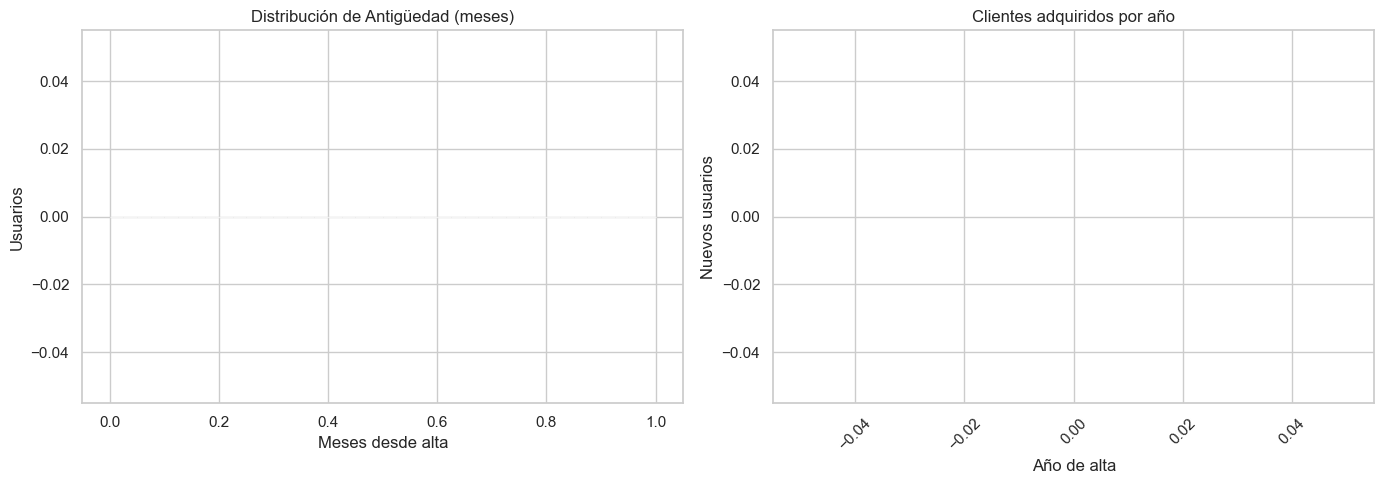


Antigüedad (meses):
count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: feat_tenure_months, dtype: float64


In [20]:
if fecha_col:
    # Parsear la fecha — intentar inferir formato automáticamente
    df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
    n_fecha_null = df[fecha_col].isna().sum()
    print(f'Fechas nulas tras parseo: {n_fecha_null:,}')
    print(f'Rango: {df[fecha_col].min()} → {df[fecha_col].max()}')

    # Calcular antigüedad en meses (respecto a la fecha más reciente del dataset)
    ref_date = df[fecha_col].max()
    df['feat_tenure_months'] = ((ref_date - df[fecha_col]) / pd.Timedelta(days=30.44)).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribución de antigüedad en meses
    axes[0].hist(df['feat_tenure_months'].dropna(), bins=40, color='teal', alpha=0.8)
    axes[0].set_title('Distribución de Antigüedad (meses)', fontsize=12)
    axes[0].set_xlabel('Meses desde alta')
    axes[0].set_ylabel('Usuarios')

    # Clientes por año de alta — ver crecimiento de la base
    df['cohort_year'] = df[fecha_col].dt.year
    cohort_counts = df['cohort_year'].value_counts().sort_index()
    axes[1].bar(cohort_counts.index.astype(str), cohort_counts.values, color='teal', alpha=0.8)
    axes[1].set_title('Clientes adquiridos por año', fontsize=12)
    axes[1].set_xlabel('Año de alta')
    axes[1].set_ylabel('Nuevos usuarios')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    print(f'\nAntigüedad (meses):')
    print(df['feat_tenure_months'].describe())
else:
    print('ℹ️  No se encontró columna de fecha de alta — feat_tenure_months no disponible')

In [21]:
# ── Indicadores de actividad ──────────────────────────────────────────────────
# Detectar columnas que indiquen si el cliente está activo
activity_col = next((c for c in df.columns if any(k in c.lower() for k in
                     ['activo', 'active', 'status', 'estado_cuenta', 'baja'])), None)
print(f'Columna de actividad detectada: {activity_col}')

if activity_col:
    print(df[activity_col].value_counts(dropna=False))
    # Crear flag binario de actividad para feature engineering
    activity_values = df[activity_col].value_counts().index
    print(f'\nValores únicos: {activity_values.tolist()}')

Columna de actividad detectada: num_productos_activos
num_productos_activos
2    4753
3    4063
1    3344
4    1731
0     817
5     317
Name: count, dtype: int64

Valores únicos: [2, 3, 1, 4, 0, 5]


### Por qué importa la antigüedad

> - **UC3 (Upselling):** clientes más antiguos tienen mayor contexto histórico y mayor probabilidad de adoptar productos nuevos.
> - **UC2 (Perfil):** la antigüedad define el "ciclo de vida financiero" del usuario — influye en la confianza y el engagement.
> - Los cohorts de adquisición revelan si la base de clientes es joven (riesgo de datos escasos) o madura.

---
## 7. Análisis de Variables Categóricas

In [22]:
# Detectar columnas categóricas: dtype object O nunique < 20
# Excluir columnas que ya analizamos y columnas ID
already_analyzed = {age_col, gender_col, state_col, seg_col, fecha_col, uid_col, 'feat_age_bin', 'cohort_year'}
already_analyzed = {c for c in already_analyzed if c is not None}

cat_cols = [
    c for c in df.columns
    if c not in already_analyzed
    and (df[c].dtype == 'object' or df[c].nunique() < 20)
    and df[c].nunique() > 1
]
print(f'Columnas categóricas para analizar: {cat_cols}')

Columnas categóricas para analizar: ['nivel_educativo', 'ocupacion', 'es_hey_pro', 'nomina_domiciliada', 'preferencia_canal', 'satisfaccion_1_10', 'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro', 'num_productos_activos', 'patron_uso_atipico']


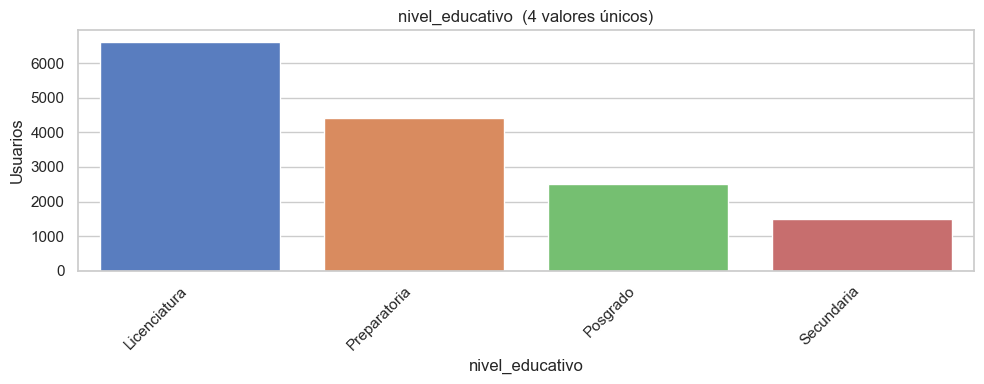

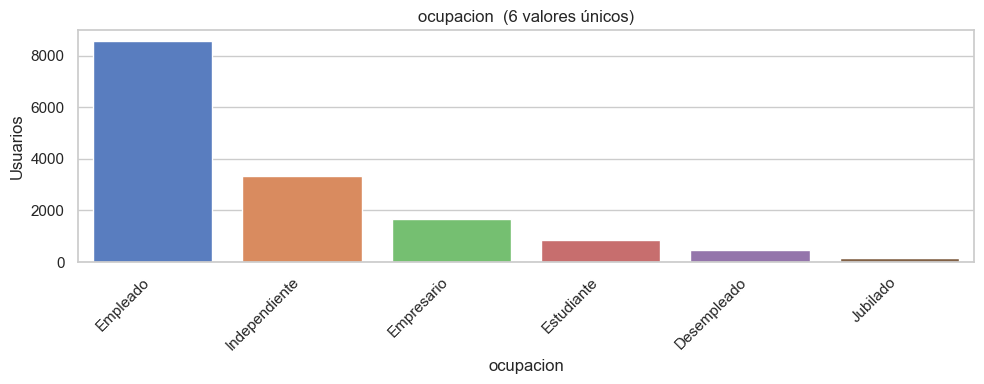

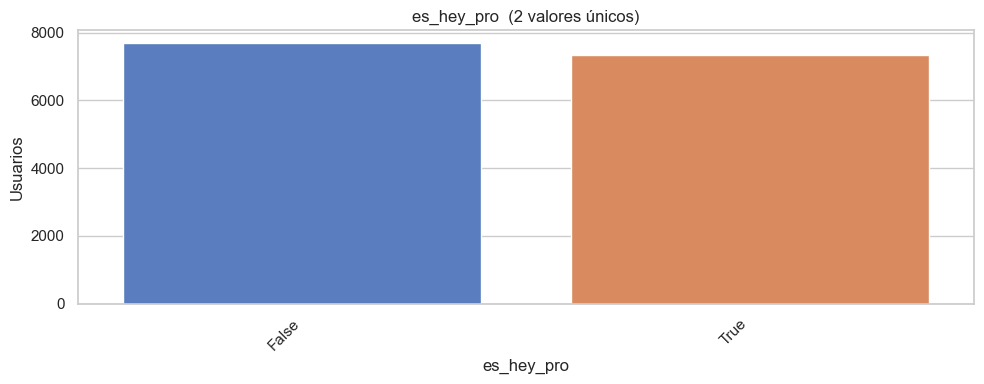

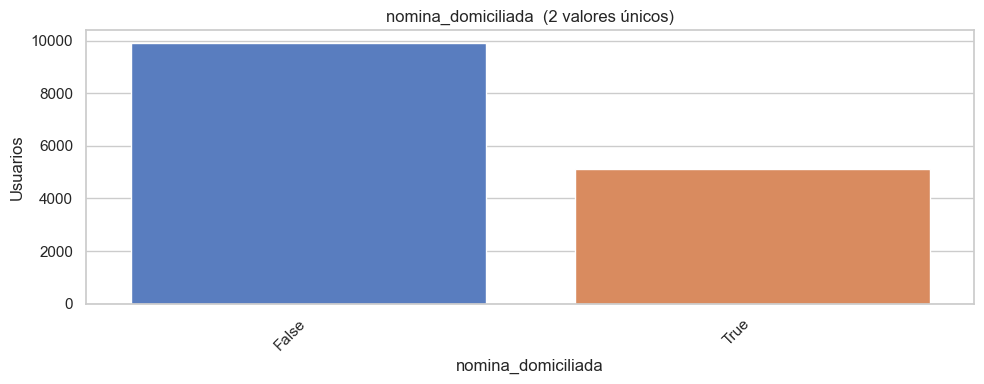

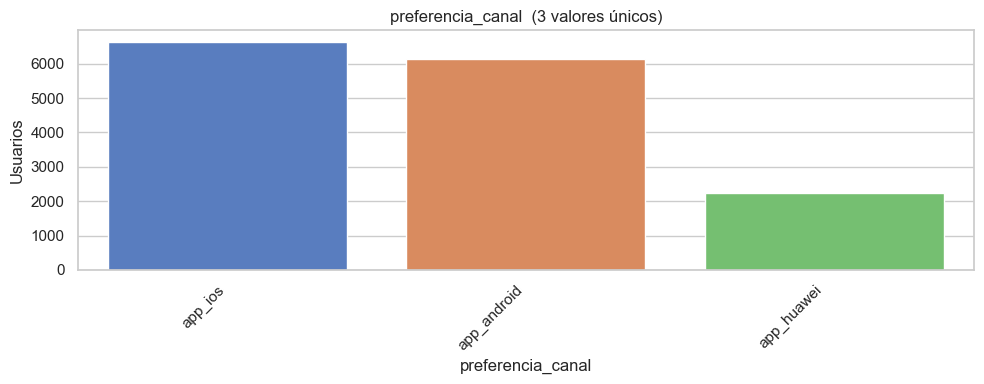

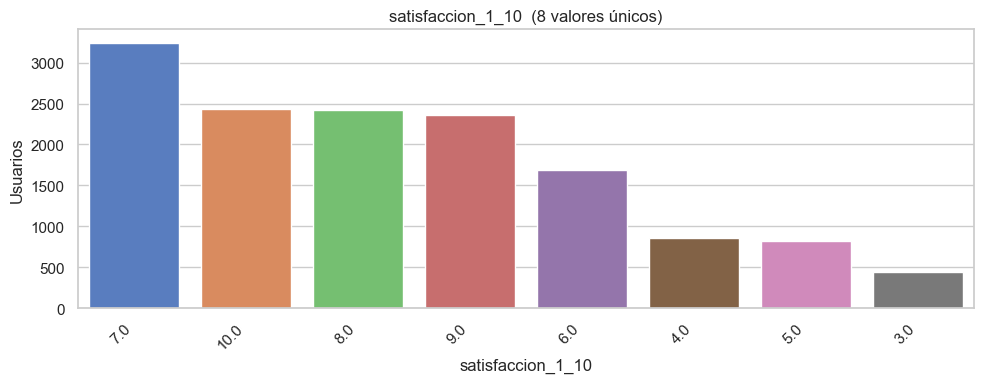

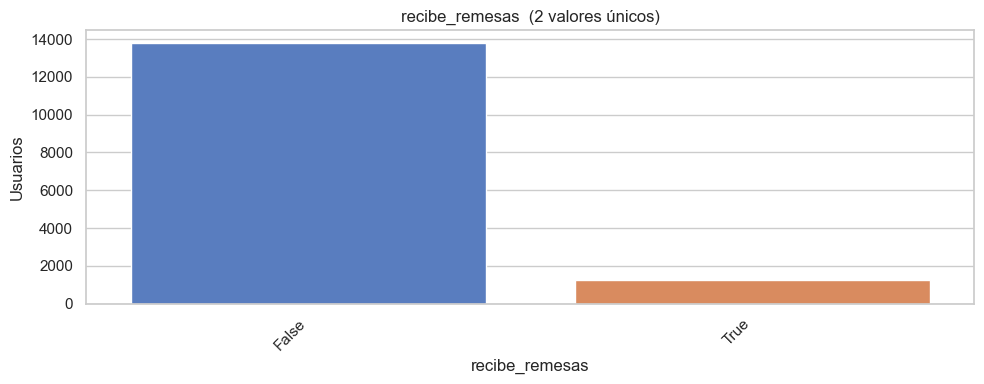

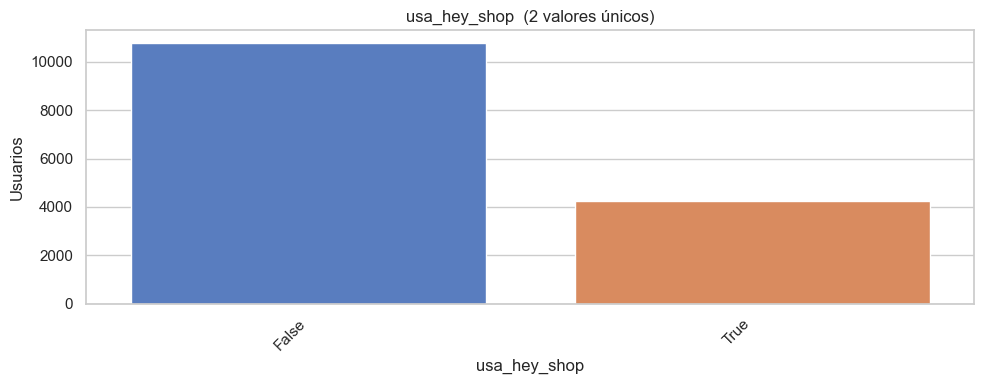

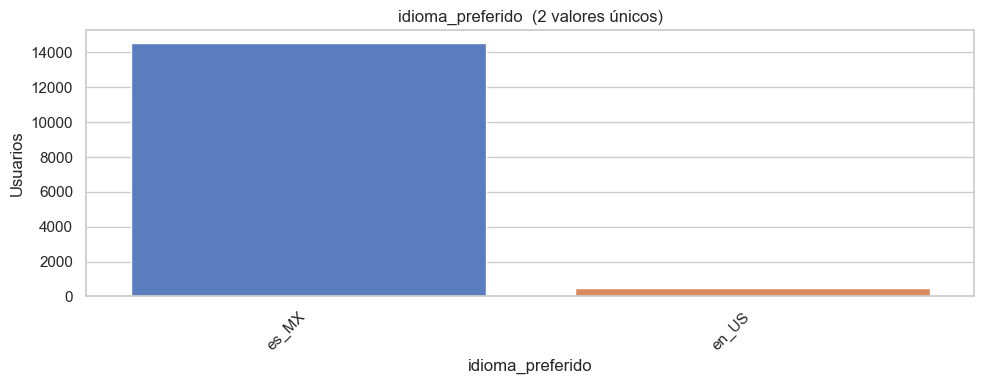

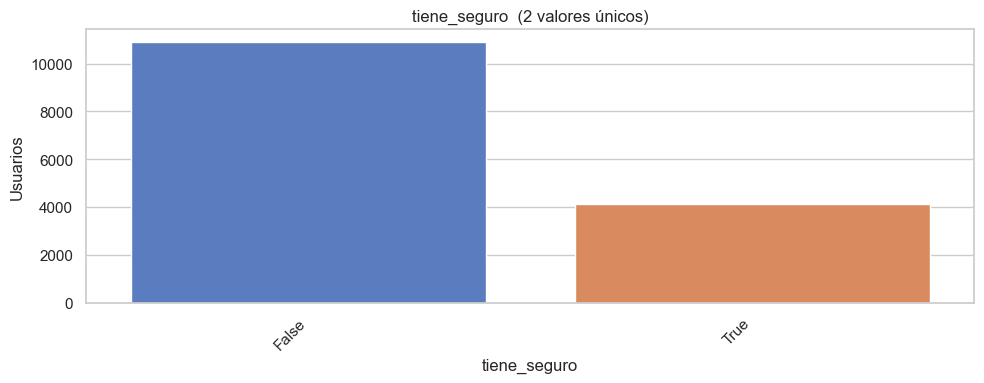

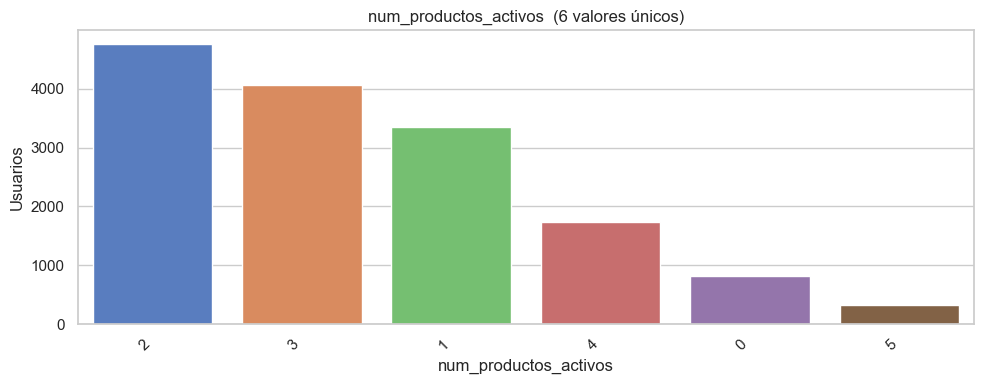

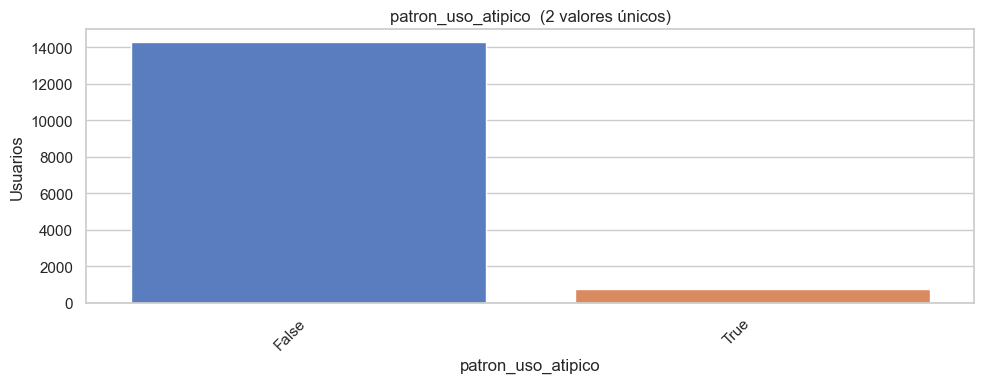

In [23]:
# Graficar distribución de cada categórica (top 15 si tiene muchos valores)
for col in cat_cols:
    n_unique = df[col].nunique()
    counts = df[col].value_counts(dropna=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette='muted', ax=ax)
    ax.set_title(f'{col}  ({n_unique} valores únicos)' + (' — top 15' if n_unique > 15 else ''), fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Usuarios')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Flag de alta cardinalidad
    if n_unique > 50:
        print(f'  ⚠️  Alta cardinalidad ({n_unique} valores) — requiere encoding o agrupación')

---
## 8. Variables Numéricas — Distribuciones

In [24]:
# Columnas numéricas — excluir IDs y features ya creadas
exclude_num = {uid_col, 'feat_tenure_months', 'feat_age_bin', 'cohort_year'}
exclude_num = {c for c in exclude_num if c is not None}

num_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c not in exclude_num and df[c].nunique() > 5
]
print(f'Columnas numéricas: {num_cols}')

Columnas numéricas: ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10', 'num_productos_activos']


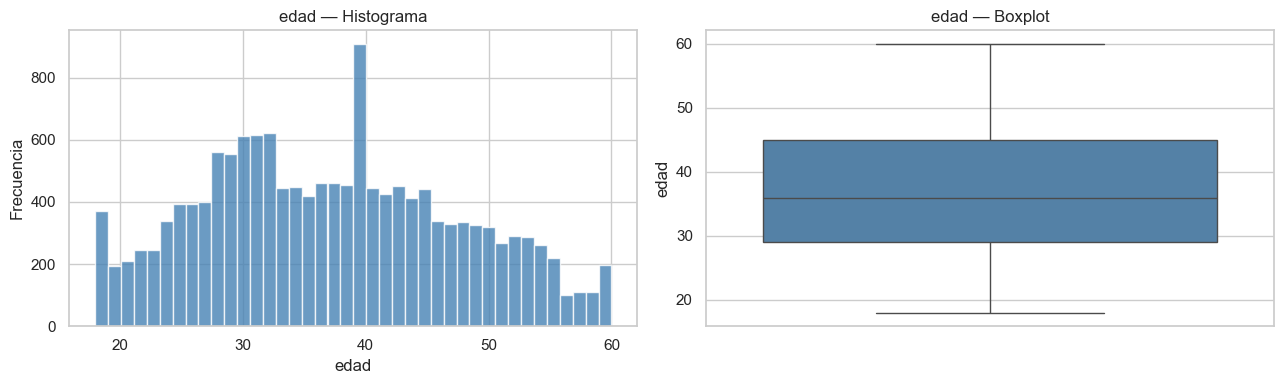

  Outliers IQR en "edad": 0 (0.0%)  — rango válido: [5.00, 69.00]


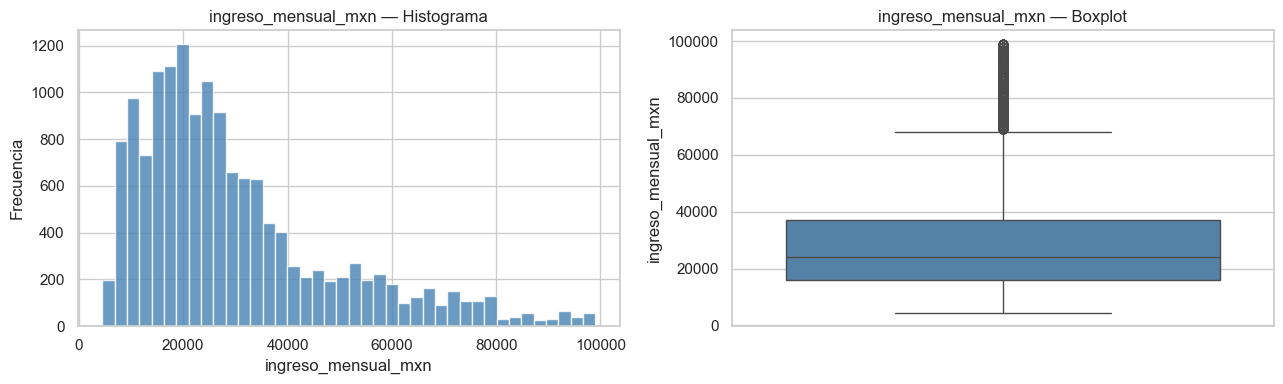

  Outliers IQR en "ingreso_mensual_mxn": 915 (6.1%)  — rango válido: [-15500.00, 68500.00]


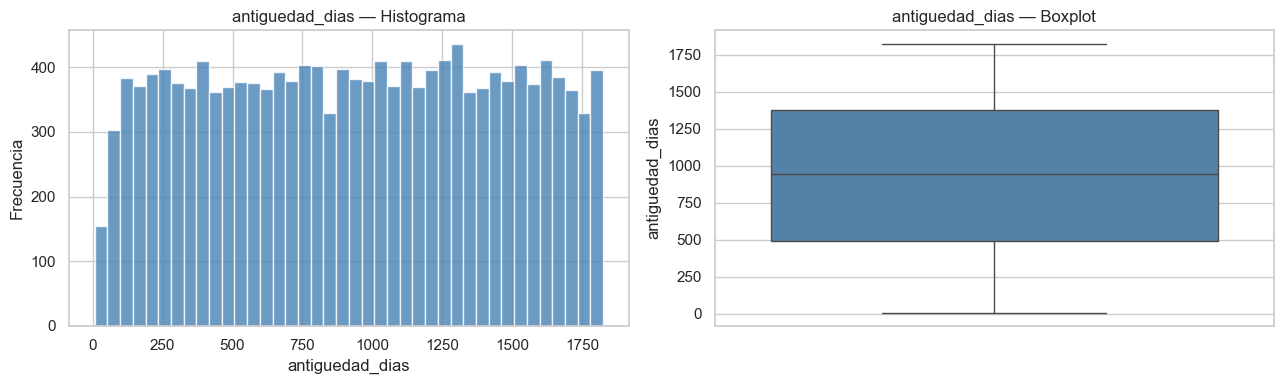

  Outliers IQR en "antiguedad_dias": 0 (0.0%)  — rango válido: [-837.50, 2702.50]


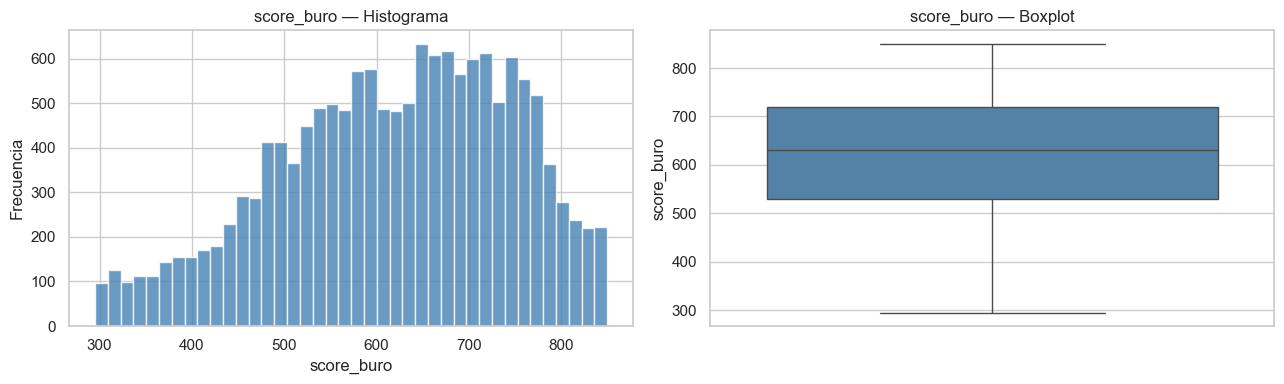

  Outliers IQR en "score_buro": 0 (0.0%)  — rango válido: [244.00, 1004.00]


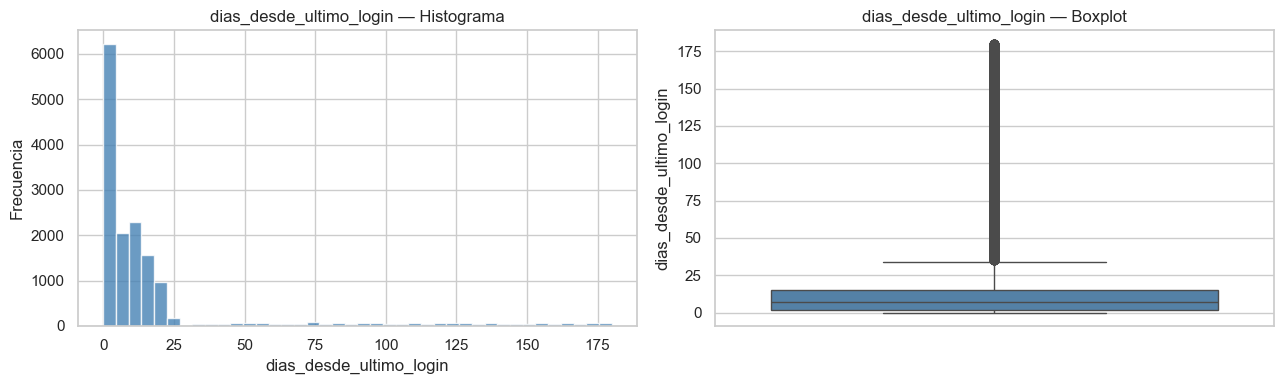

  Outliers IQR en "dias_desde_ultimo_login": 1,719 (11.4%)  — rango válido: [-17.50, 34.50]


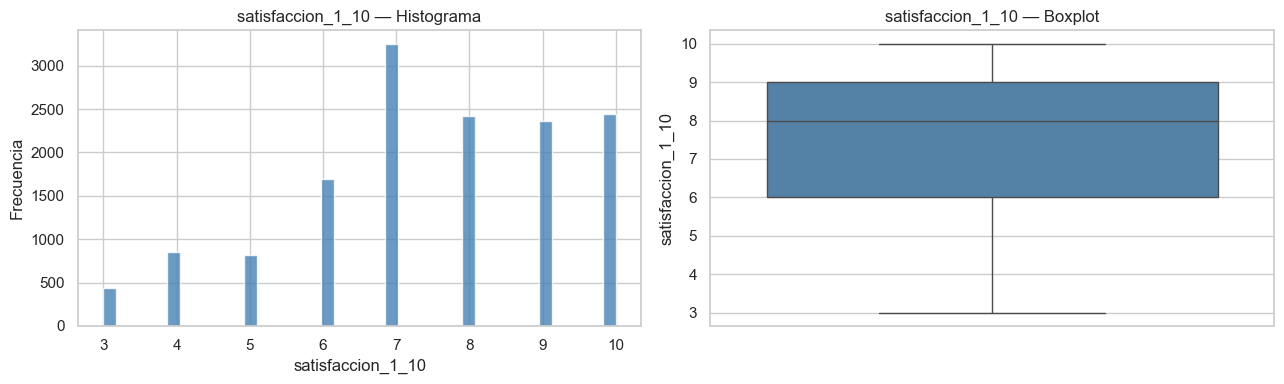

  Outliers IQR en "satisfaccion_1_10": 0 (0.0%)  — rango válido: [1.50, 13.50]


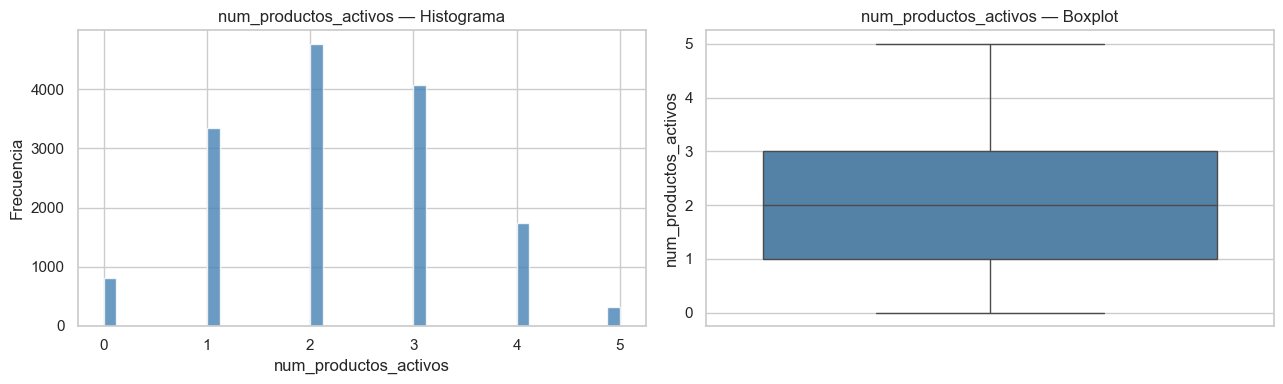

  Outliers IQR en "num_productos_activos": 0 (0.0%)  — rango válido: [-2.00, 6.00]


In [25]:
for col in num_cols:
    col_data = df[col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histograma
    axes[0].hist(col_data, bins=40, color='steelblue', alpha=0.8)
    axes[0].set_title(f'{col} — Histograma', fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(y=col_data, ax=axes[1], color='steelblue')
    axes[1].set_title(f'{col} — Boxplot', fontsize=12)
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    # Detección de outliers con IQR
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((col_data < lower) | (col_data > upper)).sum()
    pct_outliers = n_outliers / len(col_data) * 100
    print(f'  Outliers IQR en "{col}": {n_outliers:,} ({pct_outliers:.1f}%)  — rango válido: [{lower:.2f}, {upper:.2f}]')

---
## 9. Correlaciones

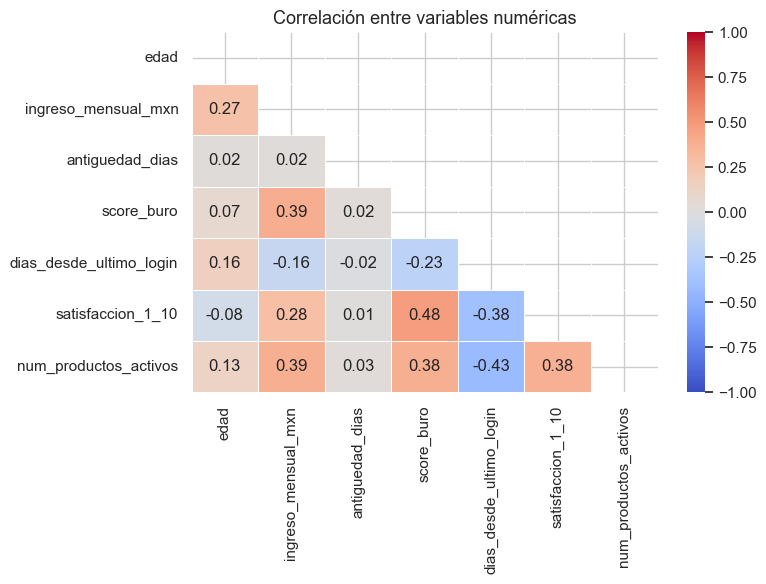

✓ No hay pares con correlación |r| > 0.7


In [26]:
# Correlación entre variables numéricas — base para feature selection
num_for_corr = df[num_cols].copy()

if len(num_cols) >= 2:
    corr_matrix = num_for_corr.corr()
    annotate = len(num_cols) <= 15  # solo anotar si hay pocas columnas

    fig, ax = plt.subplots(figsize=(max(8, len(num_cols)), max(6, len(num_cols) - 1)))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=annotate, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title('Correlación entre variables numéricas', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Pares con alta correlación (|r| > 0.7) — riesgo de multicolinealidad
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.7:
                high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

    if high_corr:
        print('\n⚠️  Pares con alta correlación (|r| > 0.7):')
        for a, b, r in high_corr:
            print(f'  {a} ↔ {b}: r = {r}')
    else:
        print('✓ No hay pares con correlación |r| > 0.7')
else:
    print('ℹ️  No hay suficientes columnas numéricas para matriz de correlación')

### Observaciones de correlación

> **[Completar después de ejecutar]**
>
> - ¿Hay variables altamente correlacionadas que impliquen redundancia?
> - ¿Alguna variable numérica se correlaciona con el segmento de cliente?
> - ¿Qué pares son interesantes para feature interactions en UC2/UC3?

---
## 10. Features Candidatas para UC2 y UC3

Basado en el análisis anterior, estas son las features que se pueden construir desde `hey_clientes.csv`:

| Feature | Descripción | UC relevante | Estado |
|---|---|---|---|
| `feat_age_bin` | Grupo etario (<25, 25-35, 35-50, 50-65, 65+) | UC2, UC3 | ✅ Ya creado en celda 4 |
| `feat_tenure_months` | Meses desde la fecha de alta | UC2, UC3 | ✅ Ya creado en celda 6 |
| `feat_segment` | Segmento de cliente codificado (label/ordinal) | UC2, UC3 | 🔲 Pendiente encoding |
| `feat_is_active` | Flag binario de actividad (1/0) | UC1, UC2, UC3 | 🔲 Pendiente si existe columna |
| `feat_state_encoded` | Estado/región codificado (target encoding recomendado) | UC2 | 🔲 Pendiente alta cardinalidad |
| `feat_gender_encoded` | Género codificado (0/1/NaN) | UC2 | 🔲 Pendiente |

### Notas de implementación

- **`feat_segment`**: si es ordinal (e.g. básico < estándar < premium), usar `OrdinalEncoder`. Si es nominal, usar `OneHotEncoder`.
- **`feat_state_encoded`**: con alta cardinalidad, preferir **target encoding** vs one-hot para evitar dimensionalidad explosiva.
- **`feat_tenure_months`**: considerar también `feat_tenure_years` y `feat_tenure_bucket` (0-1 año, 1-3, 3-5, 5+) para modelos tree-based.
- Todas las features deben construirse en `notebooks/uc2/01_feature_eng_bi.ipynb` y `notebooks/uc3/01_feature_eng_jv.ipynb` importando helpers de `src/features/`.

In [27]:
# Snapshot de features ya creadas en este notebook
feature_cols = [c for c in df.columns if c.startswith('feat_')]
print(f'Features creadas en este notebook: {feature_cols}')
if feature_cols:
    df[feature_cols].head(5)

Features creadas en este notebook: ['feat_age_bin', 'feat_tenure_months']


---
## 11. Resumen Ejecutivo

> **[Completar después de ejecutar el notebook completo]**

### Datos generales
- **Total usuarios únicos:** `[completar]`
- **Período cubierto:** `[completar si hay fecha de alta]`
- **Columnas totales:** `[completar]`

### Demografía clave
- **Grupo etario dominante:** `[completar]`
- **Distribución de género:** `[completar]`
- **Segmentos presentes:** `[completar]`
- **Top 3 estados:** `[completar]`

### Calidad de datos
- **Columnas con nulos >50%:** `[listar o "ninguna"]`
- **user_id único:** `[sí/no + detalle]`
- **Columnas constantes:** `[listar o "ninguna"]`
- **Outliers críticos:** `[detallar columnas con >5% outliers]`

### Recomendaciones
- **Columnas a dropear:** `[listar con justificación]`
- **Columnas a revisar:** `[listar con motivo]`
- **Features listas para engineering:** `feat_age_bin`, `feat_tenure_months` + pendientes de encoding

### Próximos pasos
1. Compartir hallazgos con el equipo antes de arrancar con `uc2/01_feature_eng_bi.ipynb`
2. Confirmar encoding strategy para `feat_segment` con Fernando (UC1) y Jorge (UC3)
3. Validar que `user_id` hace join limpio contra `hey_transacciones.csv` y `hey_productos.csv`

In [28]:
# Validación rápida de join keys — confirmar que user_id está en este dataset
if uid_col:
    print(f'Join key "{uid_col}":')
    print(f'  Total registros: {len(df):,}')
    print(f'  Únicos:          {df[uid_col].nunique():,}')
    print(f'  Nulos:           {df[uid_col].isna().sum():,}')
    print(f'  Tipo:            {df[uid_col].dtype}')
    print(f'\n  Muestra de IDs:  {df[uid_col].sample(5).tolist()}')

Join key "user_id":
  Total registros: 15,025
  Únicos:          15,025
  Nulos:           0
  Tipo:            str

  Muestra de IDs:  ['USR-12068', 'USR-08431', 'USR-09617', 'USR-02366', 'USR-06219']
